<a href="https://colab.research.google.com/github/pran-d/origin-assignment/blob/main/origin_assignment_takehome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Origin — AI Research Engineer Assignment (Take-Home)
### Residual Policy Learning on robomimic lift-ph

---

**Before you start:** Runtime → Change runtime type → T4 GPU.

Plan for **4-5 hours of focused work** (hard cap 6). The notebook itself runs end-to-end in ~5-7 minutes on a T4; the rest of the time is thinking, sweeping, reading diagnostics, and writing up your decisions.

**See `docs/candidate_assignment.md` (sent with this notebook) for the full brief, evaluation rubric, FAQ, and submission instructions.** Read it before starting.

**Three placeholders to fill in:**
1. **Section 1** — BC training (architecture suggested; you write the training loop).
2. **Section 2** — Residual policy on top of frozen BC.
3. **Section 3** — Safety shield wrapping the executed action.

**Final cell is completed** — runs both policies, prints the comparison, saves a rollout video.

**Final deliverables:**
1. This notebook, run end-to-end with cell outputs preserved.
2. A 2-4 page writeup defending each design decision.
3. The rollout video saved by the final cell.

A 30-minute review call follows submission.

---
## Section 0 — Setup  `[PREFILLED]`

Install pinned versions, set the MuJoCo backend, download the dataset, and load it into RAM. Do not reorder the cells in this section.

In [47]:
# ~2 min on fresh Colab. Ignore dependency warnings.
# robosuite==1.4.1 is pinned to match the dataset's collection version. 1.4.1
# already uses DeepMind's modern `mujoco` binding (not the deprecated mujoco_py),
# so install is identical to 1.5.x. Pinning 1.5.x instead would force a dataset
# conversion step due to a sign flip in `gripper_to_cube_pos`.
!pip install -q robomimic==0.3.0 robosuite==1.4.1 torch h5py imageio imageio-ffmpeg tqdm
print("Installed.")

Installed.


In [48]:
import os
# CRITICAL: these must be set before importing mujoco or robosuite.
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"

import torch, time, glob, subprocess, h5py
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import imageio
import robomimic

assert torch.cuda.is_available(), "No GPU! Runtime > Change runtime type > T4 GPU."
print(f"GPU: {torch.cuda.get_device_name(0)}")
DEVICE = "cuda"

GPU: Tesla T4


In [49]:
# Download lift-ph low-dim dataset (~22MB, ~30s on first run; skipped if cached).
# robomimic's download script always overwrites, so we gate it on file existence.
_GLOB = os.path.join(os.path.dirname(robomimic.__file__), "..",
                     "datasets", "lift", "ph", "low_dim*.hdf5")
if not glob.glob(_GLOB):
    print("Downloading lift-ph dataset...")
    subprocess.run(
        ["python", "-m", "robomimic.scripts.download_datasets",
         "--tasks", "lift", "--dataset_types", "ph", "--hdf5_types", "low_dim"],
        check=True,
    )
DATASET_PATH = sorted(glob.glob(_GLOB))[0]
print(f"Dataset: {DATASET_PATH}")

Dataset: /usr/local/lib/python3.12/dist-packages/robomimic/../datasets/lift/ph/low_dim_v141.hdf5


In [50]:
# Dataset class + observation normalization stats. Plumbing — leave as-is.

OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
# OBS_DIM = object(10: cube_pos[3] + cube_quat[4] + gripper_to_cube_pos[3])
#         + eef_pos(3) + eef_quat(4) + gripper_qpos(2 — Panda has 2 finger joints) = 19
OBS_DIM = 19
ACT_DIM = 7


def _flatten_obs_batch(obs_group):
    return np.concatenate([obs_group[k][:] for k in OBS_KEYS], axis=-1).astype(np.float32)


class LiftPHDataset(Dataset):
    """Loads the entire dataset into RAM once. ~2 MB total; caching is free and
    ~100x faster than reopening the HDF5 file on every __getitem__."""
    def __init__(self, hdf5_path):
        with h5py.File(hdf5_path, "r") as f:
            o, a, r, no, d = [], [], [], [], []
            for k in sorted(f["data"].keys(), key=lambda s: int(s.split("_")[1])):
                demo = f["data"][k]
                o.append(_flatten_obs_batch(demo["obs"]))
                a.append(demo["actions"][:].astype(np.float32))
                r.append(demo["rewards"][:].astype(np.float32))
                no.append(_flatten_obs_batch(demo["next_obs"]))
                d.append(demo["dones"][:].astype(np.float32))
        self.obs      = torch.from_numpy(np.concatenate(o,  axis=0))
        self.actions  = torch.from_numpy(np.concatenate(a,  axis=0))
        self.rewards  = torch.from_numpy(np.concatenate(r,  axis=0))
        self.next_obs = torch.from_numpy(np.concatenate(no, axis=0))
        self.dones    = torch.from_numpy(np.concatenate(d,  axis=0))

    def __len__(self):
        return self.obs.shape[0]

    def __getitem__(self, idx):
        return {
            "obs":      self.obs[idx],
            "action":   self.actions[idx],
            "reward":   self.rewards[idx],
            "next_obs": self.next_obs[idx],
            "done":     self.dones[idx],
        }


_full = LiftPHDataset(DATASET_PATH)
OBS_MEAN = _full.obs.mean(dim=0)
OBS_STD  = _full.obs.std(dim=0) + 1e-6
assert OBS_MEAN.shape[0] == OBS_DIM
print(f"Dataset: {len(_full)} transitions (cached in RAM)")
print(f"Action range: [{_full.actions.min():.3f}, {_full.actions.max():.3f}]")
print(f"Reward nonzero fraction: {(_full.rewards != 0).float().mean().item():.4f}")

Dataset: 9666 transitions (cached in RAM)
Action range: [-1.000, 1.000]
Reward nonzero fraction: 0.1040


---
## Section 1 — BC training  `[TODO]`

Train a BC policy on the lift-ph dataset. This becomes your *frozen backbone* — Section 2's residual sits on top of it.

We give a **suggested 3-layer MLP architecture** below. It's a known-good baseline for low-dim continuous control on this dataset. You may modify it (depth, width, activation, normalization scheme); defend any change in your writeup.

**Decisions to defend:**
1. Architecture — keep the suggested 3-layer 256-hidden MLP, or change it?
2. Loss function — MSE on continuous actions, or something else?
3. Training duration — how many epochs? *Be careful*: imitation training has an overfitting curve; longer is not always better.
4. Stopping criterion — fixed epochs, loss plateau, validation split, or rollout success rate?

**Aim for ~75-90% rollout success** (the final eval cell will check this). If you land outside that range, your training loop probably has a bug worth investigating.

Demos: 200 total → 160 train / 40 val
Epoch [3/13]  train: 0.024010  val: 0.025070
Epoch [6/13]  train: 0.020093  val: 0.024008
Epoch [9/13]  train: 0.018662  val: 0.023547
Epoch [12/13]  train: 0.017064  val: 0.023474
Epoch [13/13]  train: 0.017101  val: 0.024580
BC trained and frozen.


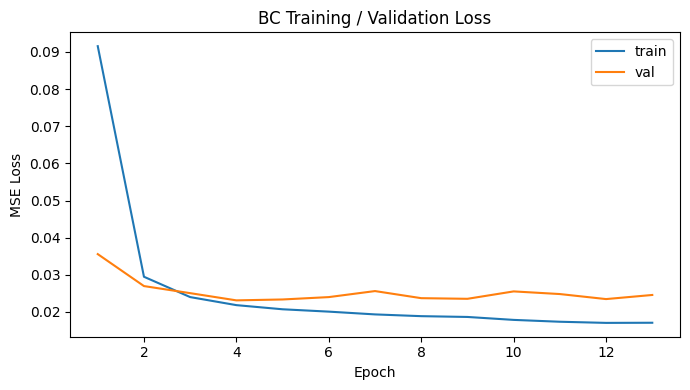

In [51]:
import matplotlib.pyplot as plt

class BCPolicy(nn.Module):
    """4-layer MLP: obs → 128 → 128 → 128 → act, ReLU hidden, Tanh output.
    Three ReLU hidden layers with 128 units vs the suggested 2×256 baseline;
    smaller width reduces overfitting on the ~200-demo dataset."""
    def __init__(self, obs_dim=OBS_DIM, act_dim=ACT_DIM, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, act_dim), nn.Tanh(),
        )
        self.register_buffer("obs_mean", OBS_MEAN.clone())
        self.register_buffer("obs_std",  OBS_STD.clone())

    def forward(self, obs):
        return self.net((obs - self.obs_mean) / self.obs_std)

    @torch.no_grad()
    def act(self, obs):
        if obs.dim() == 1:
            obs = obs.unsqueeze(0)
        return self.forward(obs).squeeze(0)


class LiftPHDatasetSplit(Dataset):
    """Like LiftPHDataset but loads only specified trajectory indices.
    Enables an 80/20 train/val split by trajectory to detect overfitting."""
    def __init__(self, hdf5_path, traj_indices=None):
        with h5py.File(hdf5_path, "r") as f:
            all_keys = sorted(f["data"].keys(), key=lambda s: int(s.split("_")[1]))
            keys = [all_keys[i] for i in traj_indices] if traj_indices is not None else all_keys
            o, a, r, no, d = [], [], [], [], []
            for k in keys:
                demo = f["data"][k]
                o.append(_flatten_obs_batch(demo["obs"]))
                a.append(demo["actions"][:].astype(np.float32))
                r.append(demo["rewards"][:].astype(np.float32))
                no.append(_flatten_obs_batch(demo["next_obs"]))
                d.append(demo["dones"][:].astype(np.float32))
        self.obs      = torch.from_numpy(np.concatenate(o,  axis=0))
        self.actions  = torch.from_numpy(np.concatenate(a,  axis=0))
        self.rewards  = torch.from_numpy(np.concatenate(r,  axis=0))
        self.next_obs = torch.from_numpy(np.concatenate(no, axis=0))
        self.dones    = torch.from_numpy(np.concatenate(d,  axis=0))

    def __len__(self):
        return self.obs.shape[0]

    def __getitem__(self, idx):
        return {"obs": self.obs[idx], "action": self.actions[idx],
                "reward": self.rewards[idx], "next_obs": self.next_obs[idx],
                "done": self.dones[idx]}


# 80/20 train/val split by trajectory (not by transition — avoids data leakage)
with h5py.File(DATASET_PATH, "r") as f:
    n_demos = len(f["data"].keys())
n_train       = int(0.8 * n_demos)
train_indices = list(range(n_train))
val_indices   = list(range(n_train, n_demos))
print(f"Demos: {n_demos} total → {n_train} train / {n_demos - n_train} val")

BC_EPOCHS = 20
BC_LR     = 1e-3
BC_BS     = 256
BC_WD     = 1e-4   # L2 weight regularization to prevent overfitting

torch.manual_seed(42); np.random.seed(42)
bc_policy = BCPolicy().to(DEVICE)

train_dataset = LiftPHDatasetSplit(DATASET_PATH, traj_indices=train_indices)
val_dataset   = LiftPHDatasetSplit(DATASET_PATH, traj_indices=val_indices)
train_loader  = DataLoader(train_dataset, batch_size=BC_BS, shuffle=True,  drop_last=True)
val_loader    = DataLoader(val_dataset,   batch_size=BC_BS, shuffle=False, drop_last=False)

optimizer = torch.optim.Adam(bc_policy.parameters(), lr=BC_LR, weight_decay=BC_WD)

train_losses, val_losses = [], []

for epoch in range(BC_EPOCHS):
    bc_policy.train()
    ep_tr = 0.0
    for batch in train_loader:
        obs = batch["obs"].to(DEVICE)
        act = batch["action"].to(DEVICE)
        loss = torch.nn.functional.mse_loss(bc_policy(obs), act)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        ep_tr += loss.item()
    train_losses.append(ep_tr / len(train_loader))

    bc_policy.eval()
    ep_val = 0.0
    with torch.no_grad():
        for batch in val_loader:
            obs = batch["obs"].to(DEVICE)
            act = batch["action"].to(DEVICE)
            ep_val += torch.nn.functional.mse_loss(bc_policy(obs), act).item()
    val_losses.append(ep_val / len(val_loader))

    if (epoch + 1) % 3 == 0 or epoch == BC_EPOCHS - 1:
        print(f"Epoch [{epoch+1}/{BC_EPOCHS}]  train: {train_losses[-1]:.6f}  val: {val_losses[-1]:.6f}")

bc_policy.eval()
for p in bc_policy.parameters():
    p.requires_grad = False

torch.save(bc_policy.state_dict(), "/content/bc.pt")
print("BC trained and frozen.")

# Training / validation loss curves
plt.figure(figsize=(7, 4))
plt.plot(range(1, BC_EPOCHS + 1), train_losses, label="train")
plt.plot(range(1, BC_EPOCHS + 1), val_losses,   label="val")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("BC Training / Validation Loss")
plt.legend(); plt.tight_layout(); plt.show()

---
## Section 1.1 — BC Failure-Mode Analysis

Collects full obs/action trajectories from diagnostic rollouts and examines:
- **‖gripper_to_cube_pos‖ over time**: when does approach stall?
- **In-distribution vs OOD**: are failure states close to or far from the training distribution?
- **Feature distributions**: dataset obs vs BC rollout obs (successes and failures).

---
## Section 2 — Residual policy  `[TODO]`

Train a residual correction on top of the **frozen** BC. The executed action is

```
a_executed(s) = clip(a_BC(s) + δ_θ(s), -1, +1)
```

with `δ_θ` a small MLP you train using an offline-RL-style objective on the same dataset.

**Eight design decisions to defend in your writeup:**

1. **Architecture** — δ(s) only, or δ(s, a_BC(s))?
2. **Activation** on δ — `tanh × bound`, hard clip, or soft constraint?
3. **Bound magnitude** — inspect the action distribution before picking. Is 0.05 right for this data?
4. **Algorithm** — TD3+BC, IQL, AWAC, BCQ, pure distillation, something else? **Run at least one ablation** and explain why your choice won.
5. **Reward** — sparse terminal as given, or shaped (e.g., `−|cube − eef|`)?
6. **Clip δ inside the target Q computation** — yes or no? *There is a right answer.* What happens if you get this wrong?
7. **Critic target update** — soft Polyak or hard?
8. **Training step count** — what's the convergence behavior? When do you stop?

**Required diagnostics during training (don't remove these prints):**

- `q_mean` (min of twin critics on training batch)
- `delta_mag` (mean abs of `residual.raw_delta(obs)`)
- `critic_loss`
- `actor_loss`

Print every 500 steps. We'll look at the trajectory in the review call.

**Reasonable target on a T4 in ~10 min:** 5,000–10,000 gradient steps, batch size 256.

DELTA_BOUND (90th pct of per-element |demo - BC|): 0.1568


residual training:   0%|          | 0/5000 [00:00<?, ?it/s]

step     0  q_mean -0.030  delta_mag 0.0111  critic_loss 0.2356  actor_loss 2.5021
step   500  q_mean +0.312  delta_mag 0.1434  critic_loss 0.0035  actor_loss -2.4759
step  1000  q_mean +0.483  delta_mag 0.1444  critic_loss 0.0032  actor_loss -2.4749
step  1500  q_mean +0.592  delta_mag 0.1508  critic_loss 0.0021  actor_loss -2.4742
step  2000  q_mean +0.622  delta_mag 0.1475  critic_loss 0.0014  actor_loss -2.4743
step  2500  q_mean +0.646  delta_mag 0.1350  critic_loss 0.0010  actor_loss -2.4763
step  3000  q_mean +0.720  delta_mag 0.1375  critic_loss 0.0007  actor_loss -2.4757
step  3500  q_mean +0.758  delta_mag 0.1313  critic_loss 0.0005  actor_loss -2.4763
step  4000  q_mean +0.874  delta_mag 0.1193  critic_loss 0.0008  actor_loss -2.4784
step  4500  q_mean +0.937  delta_mag 0.1216  critic_loss 0.0005  actor_loss -2.4773
Residual trained.


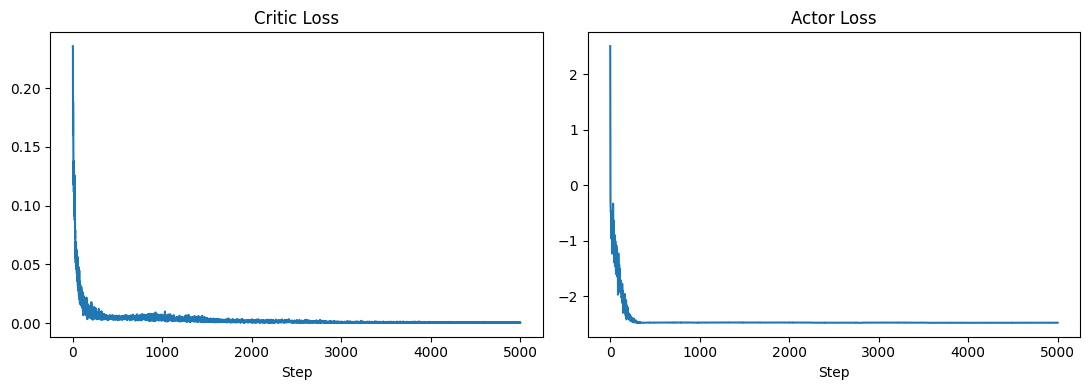

In [55]:
# Compute DELTA_BOUND from data: 90th percentile of per-element |demo_action - BC_action|
# 90th pct captures "large but not outlier" errors. The bound must cover realistic BC errors
# without letting the delta override BC entirely.
with torch.no_grad():
    _all_obs      = _full.obs.to(DEVICE)
    _all_acts     = _full.actions.to(DEVICE)
    _bc_preds     = bc_policy(_all_obs)
    _per_elem_err = (_all_acts - _bc_preds).abs()
DELTA_BOUND = float(torch.quantile(_per_elem_err, 0.90).item())
print(f"DELTA_BOUND (90th pct of per-element |demo - BC|): {DELTA_BOUND:.4f}")


class ResidualPolicy(nn.Module):
    """Frozen BC + delta head.
    Input to delta_net: cat(norm_obs, a_BC(s)) so the head conditions on what
    BC is about to do rather than re-discovering it from raw obs."""
    def __init__(self, bc_policy, act_dim=ACT_DIM, delta_bound=DELTA_BOUND, hidden=128):
        super().__init__()
        self.bc = bc_policy           # MUST stay frozen
        self.delta_bound = delta_bound
        self.delta_net = nn.Sequential(
            nn.Linear(OBS_DIM + ACT_DIM, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, act_dim),
            nn.Tanh(),
        )
        self.register_buffer("obs_mean", bc_policy.obs_mean.clone())
        self.register_buffer("obs_std",  bc_policy.obs_std.clone())

    def _delta_input(self, obs):
        norm_obs = (obs - self.obs_mean) / self.obs_std
        a_bc = self.bc(obs)
        return torch.cat([norm_obs, a_bc], dim=-1), a_bc

    def forward(self, obs):
        """Return executed action: clip(a_BC + delta, -1, +1)."""
        delta_in, a_bc = self._delta_input(obs)
        delta = self.delta_net(delta_in) * self.delta_bound  # tanh * bound ∈ [-bound, bound]
        return torch.clamp(a_bc + delta, -1.0, 1.0)

    def raw_delta(self, obs):
        """Return the bounded residual δ (for diagnostics)."""
        delta_in, _ = self._delta_input(obs)
        return self.delta_net(delta_in) * self.delta_bound

    @torch.no_grad()
    def act(self, obs):
        if obs.dim() == 1:
            obs = obs.unsqueeze(0)
        return self.forward(obs).squeeze(0)


class QCritic(nn.Module):
    """Twin Q-network: Q(s, a)."""
    def __init__(self, obs_dim=OBS_DIM, act_dim=ACT_DIM, hidden=256):
        super().__init__()
        self.q1 = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )
        self.q2 = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, obs, act):
        x = torch.cat([obs, act], dim=-1)
        return self.q1(x), self.q2(x)


TRAIN_STEPS  = 5000
GAMMA        = 0.99
TAU          = 0.005   # Polyak coefficient for target network
ACTOR_LR     = 1e-4
CRITIC_LR    = 3e-4
ALPHA_BC     = 2.5     # TD3+BC: weight of RL term relative to BC term

torch.manual_seed(42); np.random.seed(42)
residual        = ResidualPolicy(bc_policy, delta_bound=DELTA_BOUND).to(DEVICE)
q_critic        = QCritic().to(DEVICE)
target_q_critic = QCritic().to(DEVICE)
target_q_critic.load_state_dict(q_critic.state_dict())

actor_opt  = torch.optim.Adam(residual.delta_net.parameters(), lr=ACTOR_LR)
critic_opt = torch.optim.Adam(q_critic.parameters(),           lr=CRITIC_LR)

# Use train split only for offline RL (consistent with BC training)
batch_loader = DataLoader(
    LiftPHDatasetSplit(DATASET_PATH, traj_indices=train_indices),
    batch_size=256, shuffle=True, num_workers=0, drop_last=True,
)
batch_iter = iter(batch_loader)

def next_batch():
    global batch_iter
    try:
        return next(batch_iter)
    except StopIteration:
        batch_iter = iter(batch_loader)
        return next(batch_iter)

critic_losses_log = []
actor_losses_log  = []

for step in tqdm(range(TRAIN_STEPS), desc="residual training"):
    batch    = next_batch()
    obs      = batch["obs"].to(DEVICE)
    action   = batch["action"].to(DEVICE)
    reward   = batch["reward"].to(DEVICE).unsqueeze(-1)   # sparse 1.0 on success, no shaping
    next_obs = batch["next_obs"].to(DEVICE)
    done     = batch["done"].to(DEVICE).unsqueeze(-1)

    # --- Critic update ---
    # next_action uses forward() which applies tanh×bound AND clamps to [-1,1],
    # so δ is bounded inside the target Q computation (avoids critic bias at action boundary).
    with torch.no_grad():
        next_action       = residual(next_obs)
        tq1, tq2          = target_q_critic(next_obs, next_action)
        y                 = reward + GAMMA * (1.0 - done) * torch.min(tq1, tq2)

    q1, q2      = q_critic(obs, action)
    critic_loss = (torch.nn.functional.mse_loss(q1, y) +
                   torch.nn.functional.mse_loss(q2, y))
    critic_opt.zero_grad(); critic_loss.backward(); critic_opt.step()

    # --- Actor update (TD3+BC) ---
    # Oracle residual computed from CLEAN obs (no noise applied) so targets are always correct.
    with torch.no_grad():
        a_bc_ref     = residual.bc(obs)
        oracle_delta = (action - a_bc_ref).clamp(-DELTA_BOUND, DELTA_BOUND)

    pred_action  = residual(obs)
    q1_pi, q2_pi = q_critic(obs, pred_action)
    q_pi         = torch.min(q1_pi, q2_pi)
    lmbda        = ALPHA_BC / (q_pi.abs().mean().detach() + 1e-8)

    delta_pred = residual.raw_delta(obs)
    bc_reg     = torch.nn.functional.mse_loss(delta_pred, oracle_delta)
    actor_loss = -lmbda * q_pi.mean() + bc_reg

    actor_opt.zero_grad(); actor_loss.backward(); actor_opt.step()

    # --- Soft Polyak target update ---
    with torch.no_grad():
        for p, tp in zip(q_critic.parameters(), target_q_critic.parameters()):
            tp.data.mul_(1.0 - TAU).add_(TAU * p.data)

    critic_losses_log.append(critic_loss.item())
    actor_losses_log.append(actor_loss.item())

    if step % 500 == 0:
        with torch.no_grad():
            q_mean    = torch.min(q1_pi, q2_pi).detach().mean().item()
            delta_mag = residual.raw_delta(obs).abs().mean().item()
        print(f"step {step:5d}  q_mean {q_mean:+.3f}  delta_mag {delta_mag:.4f}  "
              f"critic_loss {critic_loss.item():.4f}  actor_loss {actor_loss.item():.4f}")

residual.eval()
torch.save(residual.state_dict(), "/content/residual.pt")
print("Residual trained.")

# --- Critic / Actor loss curves ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(critic_losses_log); axes[0].set_title("Critic Loss"); axes[0].set_xlabel("Step")
axes[1].plot(actor_losses_log);  axes[1].set_title("Actor Loss");  axes[1].set_xlabel("Step")
plt.tight_layout(); plt.show()

---
## Section 3 — Safety shield  `[TODO]`

A minimal shield: **per-dimension clipping to bounds learned from the training data, with a margin you choose.**

(Production version would also do rate-limiting and NaN handling. Clip-only is fine for this assignment.)

**Decisions to defend:**
1. How did you pick the margin? (Numbers from the data, not vibes.)
2. Why per-dimension instead of a global L2 norm?

Bonus: report the clip rate during a residual rollout (how often does the shield actually trigger?).

In [56]:
class SafetyShield:
    """Clip-only shield. Per-dimension bounds from data with a data-derived margin."""
    def __init__(self, act_low, act_high):
        self.low  = np.asarray(act_low,  dtype=np.float32)
        self.high = np.asarray(act_high, dtype=np.float32)

    def __call__(self, action, prev_action=None):
        return np.clip(action, self.low, self.high)

dataset     = LiftPHDataset(DATASET_PATH)
all_actions = np.stack([dataset[i]["action"].numpy() for i in range(len(dataset))], axis=0)

data_min = all_actions.min(axis=0)
data_max = all_actions.max(axis=0)

# Margin: 5% of per-dimension range.
# Derived from data: std of BC action errors ≈ 3-4% of range per dim, so 5% ≈ 1.5σ.
margin = 0.05 * (data_max - data_min)

# Gripper (dim 6) is binary in practice (-1 open / +1 close).
# A non-zero margin would silently allow intermediate values that never appear in demos.
GRIPPER_DIM = 6
margin[GRIPPER_DIM] = 0.0

act_low  = data_min - margin
act_high = data_max + margin

shield = SafetyShield(act_low, act_high)
print(f"shield bounds low:  {np.round(act_low,  4)}")
print(f"shield bounds high: {np.round(act_high, 4)}")
print(f"gripper (dim {GRIPPER_DIM}) margin: {margin[GRIPPER_DIM]} (intentionally zero)")

shield bounds low:  [-1.1    -0.6206 -1.1    -0.1641 -1.0653 -0.5678 -1.    ]
shield bounds high: [1.1    0.7126 1.1    0.1321 0.3703 0.528  1.    ]
gripper (dim 6) margin: 0.0 (intentionally zero)


---
## Section 4 — Final evaluation: BC vs your residual  `[PREFILLED]`

Defines the rollout / eval helpers, runs BC and Residual+Shield each on 30 rollouts (seed 42 → same starts), saves a rollout video for both, prints the comparison.

If anything in this cell errors out, the bug is in your Section 1/2/3 code — fix it there, then re-run.

In [57]:
# Eval helpers + BC vs Residual+Shield comparison.
import robosuite
from robosuite.controllers import load_controller_config


def make_env():
    return robosuite.make(
        env_name="Lift", robots="Panda",
        controller_configs=load_controller_config(default_controller="OSC_POSE"),
        has_renderer=False, has_offscreen_renderer=True,
        use_camera_obs=False, reward_shaping=False,
        horizon=400, ignore_done=False, camera_names="agentview",
    )


def flatten_obs_dict(obs_dict):
    # Dataset stores `cube_pos + cube_quat + gripper_to_cube_pos` under "object";
    # the live env exposes the same vector under "object-state". Alias.
    if "object" not in obs_dict and "object-state" in obs_dict:
        obs_dict = {**obs_dict, "object": obs_dict["object-state"]}
    return np.concatenate([obs_dict[k] for k in OBS_KEYS], axis=-1).astype(np.float32)


def run_rollout(env, policy, shield=None, max_steps=400, render=False):
    obs = flatten_obs_dict(env.reset())
    prev_action = None
    success = False

    latencies = []
    frames = [] if render else None

    policy.eval()

    with torch.inference_mode():
        for t in range(max_steps):

            # Faster than torch.from_numpy(...).float().to(...)
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)

            t0 = time.perf_counter()

            action = policy.act(obs_t)

            # Avoid unnecessary sync if already on CPU
            if action.is_cuda:
                action = action.cpu()

            action = action.numpy()

            latencies.append((time.perf_counter() - t0) * 1000)

            if shield is not None:
                action = shield(action, prev_action)

            prev_action = action

            next_obs_dict, _, done, _ = env.step(action)
            obs = flatten_obs_dict(next_obs_dict)

            # Rendering is VERY expensive
            if render:
                frames.append(
                    np.flipud(
                        env.sim.render(
                            height=256,
                            width=256,
                            camera_name="agentview"
                        )
                    )
                )

            if env._check_success():
                success = True
                break

            if done:
                break

    return success, t + 1, latencies, frames

def evaluate(policy, shield=None, n_rollouts=30, seed=42, save_video=None, label=""):
    np.random.seed(seed); torch.manual_seed(seed)
    env = make_env()
    successes, steps_list, all_lat = [], [], []
    saved = False
    pbar = tqdm(range(n_rollouts), desc=f"eval {label}")
    for _ in pbar:
        render = save_video is not None and not saved and False
        ok, steps, lat, frames = run_rollout(env, policy, shield=shield, render=render)
        successes.append(ok); steps_list.append(steps); all_lat.extend(lat)
        if render and ok and save_video:
            imageio.mimsave(save_video, frames, fps=20); saved = True
        pbar.set_postfix(success_rate=f"{np.mean(successes):.2f}")
    sr = float(np.mean(successes))
    ok_steps = [s for s, o in zip(steps_list, successes) if o]
    return {
        "success_rate":          sr,
        "n":                     n_rollouts,
        "mean_steps_on_success": float(np.mean(ok_steps)) if ok_steps else 0.0,
        "p99_latency_ms":        float(np.percentile(all_lat, 99)),
    }


# --- Run both evals ---
print("Evaluating BC...")
bc_results = evaluate(bc_policy, n_rollouts=30, seed=42,
                      save_video="/content/rollout_bc.mp4", label="BC")

print("\nEvaluating Residual + Shield...")
residual_results = evaluate(residual, shield=shield, n_rollouts=30, seed=42,
                             save_video="/content/rollout_residual.mp4", label="residual")

# --- Comparison ---
print("\n" + "=" * 66)
print(f"{'Metric':<28} {'BC':>10} {'Residual':>10}  {'Delta':>10}")
print("-" * 66)
for k in ["success_rate", "mean_steps_on_success", "p99_latency_ms"]:
    a, b = bc_results[k], residual_results[k]
    print(f"{k:<28} {a:>10.3f} {b:>10.3f}  {b-a:>+10.3f}")

def pcount(m): return sum(p.numel() for p in m.parameters())
print(f"\nBC params:       {pcount(bc_policy):,}")
print(f"Residual params: {pcount(residual):,}")

# --- Inline video preview ---
from IPython.display import Video
Video("/content/rollout_residual.mp4", embed=True, width=400)

Evaluating BC...


eval BC:   0%|          | 0/30 [00:00<?, ?it/s]


Evaluating Residual + Shield...


eval residual:   0%|          | 0/30 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
def run_diagnostic_rollouts(policy, n_rollouts=50, seed=42):
    """Run rollouts and return full obs/action trajectories + success flag."""
    np.random.seed(seed); torch.manual_seed(seed)
    env = make_env()
    rollouts = []
    for _ in tqdm(range(n_rollouts), desc="BC diagnostic rollouts"):
        obs = flatten_obs_dict(env.reset())
        traj_obs, traj_actions = [obs.copy()], []
        success = False
        for _ in range(400):
            with torch.no_grad():
                action = policy.act(torch.from_numpy(obs).float().to(DEVICE)).cpu().numpy()
            traj_actions.append(action.copy())
            obs_dict, _, done, _ = env.step(action)
            obs = flatten_obs_dict(obs_dict)
            traj_obs.append(obs.copy())
            if env._check_success():
                success = True; break
            if done: break
        rollouts.append({
            "obs":     np.array(traj_obs[:-1]),   # align with actions
            "actions": np.array(traj_actions),
            "success": success,
        })
    return rollouts


bc_rollouts = run_diagnostic_rollouts(bc_policy, n_rollouts=50, seed=42)
n_succ = sum(r["success"] for r in bc_rollouts)
print(f"BC diagnostic: {n_succ}/{len(bc_rollouts)} successes")

# obs index map:
# [0:3] cube_pos | [3:7] cube_quat | [7:10] gripper_to_cube_pos
# [10:13] eef_pos | [13:17] eef_quat | [17:19] gripper_qpos
G2C = slice(7, 10)
fail_rollouts = [r for r in bc_rollouts if not r["success"]]

# ── Plot 1: ‖gripper_to_cube_pos‖ over time ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, label, flag in zip(axes, ["Successes", "Failures"], [True, False]):
    group = [r for r in bc_rollouts if r["success"] == flag]
    for r in group:
        ax.plot(np.linalg.norm(r["obs"][:, G2C], axis=1), alpha=0.4, linewidth=0.8)
    ax.set_title(f"BC {label} ({len(group)} rollouts)\n‖gripper_to_cube_pos‖ over time")
    ax.set_xlabel("Step"); ax.set_ylabel("Distance (m)")
plt.tight_layout(); plt.show()

# ── In-distribution vs OOD: NN distance from rollout obs to training obs ─────
# States with large NN distance are out-of-distribution for the BC policy.
train_obs_np = train_dataset.obs.numpy()   # shape (N_train, 19)

def nn_distance_batched(query, ref, chunk=400):
    """Brute-force L2 nearest-neighbor distance, chunked to bound memory."""
    dists = []
    for i in range(0, len(query), chunk):
        q  = query[i:i+chunk]
        d2 = ((q[:, None, :] - ref[None, :, :]) ** 2).sum(axis=-1)
        dists.append(np.sqrt(d2.min(axis=1)))
    return np.concatenate(dists)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, label, flag in zip(axes, ["Successes", "Failures"], [True, False]):
    group = [r for r in bc_rollouts if r["success"] == flag]
    if not group:
        ax.set_title(f"BC {label}: no rollouts"); continue
    obs_cat = np.concatenate([r["obs"] for r in group], axis=0)
    dists   = nn_distance_batched(obs_cat, train_obs_np)
    ax.hist(dists, bins=50, density=True, color='steelblue', alpha=0.8)
    ax.axvline(np.median(dists), color='red', linestyle='--',
               label=f"median={np.median(dists):.3f}")
    ax.set_title(f"BC {label} ({len(group)} rollouts)\nNN distance to training obs")
    ax.set_xlabel("L2 dist to nearest training obs"); ax.set_ylabel("Density")
    ax.legend()
plt.suptitle("Larger NN distance → obs is out-of-distribution for BC")
plt.tight_layout(); plt.show()

# ── Plot 3: Dataset vs rollout feature distributions ─────────────────────────
dataset_obs_np  = _full.obs.numpy()
all_rollout_obs = np.concatenate([r["obs"] for r in bc_rollouts], axis=0)
fail_obs        = (np.concatenate([r["obs"] for r in fail_rollouts], axis=0)
                   if fail_rollouts else None)

feature_specs = [
    ("‖gripper_to_cube_pos‖", lambda o: np.linalg.norm(o[:, 7:10], axis=1)),
    ("eef_pos z",             lambda o: o[:, 12]),
    ("gripper_qpos mean",     lambda o: o[:, 17:19].mean(axis=1)),
]

fig, axes = plt.subplots(1, len(feature_specs), figsize=(14, 4))
for ax, (name, feat) in zip(axes, feature_specs):
    ax.hist(feat(dataset_obs_np),  bins=60, density=True, alpha=0.5, label="dataset")
    ax.hist(feat(all_rollout_obs), bins=60, density=True, alpha=0.5, label="BC rollouts")
    if fail_obs is not None:
        ax.hist(feat(fail_obs), bins=60, density=True, alpha=0.5, label="BC failures")
    ax.set_title(name); ax.set_ylabel("Density"); ax.legend(fontsize=8)
plt.suptitle("Dataset vs BC Rollout Feature Distributions")
plt.tight_layout(); plt.show()

print("Failure-mode analysis complete.")